# Does Work
### 17-07-2026 Does not need any changes

# 4.16 S21 simulation of a resonator

Authors: Sara Buhktari, Christian Kraglund Andersen


> 💡 **Using this tutorial without the Qt GUI**
> 
> This tutorial uses the desktop `MetalGUI`. To follow along on Colab, Binder, JupyterHub, or any environment where Qt isn't available, **replace any `gui.rebuild()` / `gui.screenshot()` call with `qm.view(design)`** — it renders the design to a matplotlib `Figure` you can display inline or save with `fig.savefig(...)`.
> 
> See [1.1 Quick start](../1-Overview/1.1-Quick-start.ipynb) for a complete runnable walkthrough and [`docs/headless-usage.rst`](../../../docs/headless-usage.rst) for the full reference.

In [1]:
# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import (
    LaunchpadWirebondDriven,
)
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

## Set up the design

In [2]:
# Set up chip dimensions
design = designs.DesignPlanar()
design._chips["main"]["size"]["size_x"] = "9mm"
design._chips["main"]["size"]["size_y"] = "9mm"

# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables["cpw_width"] = "15 um"  # S from reference 2
design.variables["cpw_gap"] = "9 um"  # W from reference 2


design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
gui = MetalGUI(design)

In [3]:
# Define for renderer
eig_qres = EPRanalysis(design, "hfss")
hfss = design.renderers.hfss
hfss = eig_qres.sim.renderer
q3d = design.renderers.q3d

## Define the geometry

Here we will have a single feedline couple to a single CPW resonator.

The lauchpad should be included in the driven model simulations.

For that reason, we use the LaunchpadWirebondDriven component which has an extra pin for input/output

In [4]:
###################
# Single feedline #
###################

# Driven Lauchpad 1
x = "-1.5mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="360", lead_length="30um"
)
LP1 = LaunchpadWirebondDriven(design, "LP1", options=launch_options)

# Driven Launchpad 2
x = "1.5mm"
y = "2.0mm"
launch_options = dict(
    chip="main", pos_x=x, pos_y=y, orientation="180", lead_length="30um"
)
LP2 = LaunchpadWirebondDriven(design, "LP2", options=launch_options)

# Using path finder to connect the two launchpads
TL_LP1_LP2 = RoutePathfinder(
    design,
    "TL_LP1_LP2",
    options=dict(
        chip="main",
        trace_width="15um",
        trace_gap="9um",
        fillet="99um",
        hfss_wire_bonds=True,
        lead=dict(end_straight="1.972mm"),
        pin_inputs=Dict(
            start_pin=Dict(component="LP1", pin="tie"),
            end_pin=Dict(component="LP2", pin="tie"),
        ),
    ),
)


# Rebuild the GUI
gui.rebuild()

In [5]:
######################
# lambda/2 resonator #
######################

# First we define the two end-points
otg1 = OpenToGround(
    design,
    "otg1s",
    options=dict(chip="main", pos_x="-0.3mm", pos_y="1.968mm", orientation="180"),
)
otg2 = OpenToGround(
    design,
    "otg1e",
    options=dict(chip="main", pos_x="0.0mm", pos_y="0.0mm", orientation="270"),
)

# Use RouteMeander to fix the total length of the resonator
rt_meander = RouteMeander(
    design,
    "meander",
    Dict(
        trace_width="12um",
        trace_gap="5um",
        total_length="8.0mm",
        hfss_wire_bonds=True,
        fillet="99 um",
        lead=dict(start_straight="250um"),
        pin_inputs=Dict(
            start_pin=Dict(component="otg1s", pin="open"),
            end_pin=Dict(component="otg1e", pin="open"),
        ),
    ),
)

# rebuild the GUI
gui.rebuild()

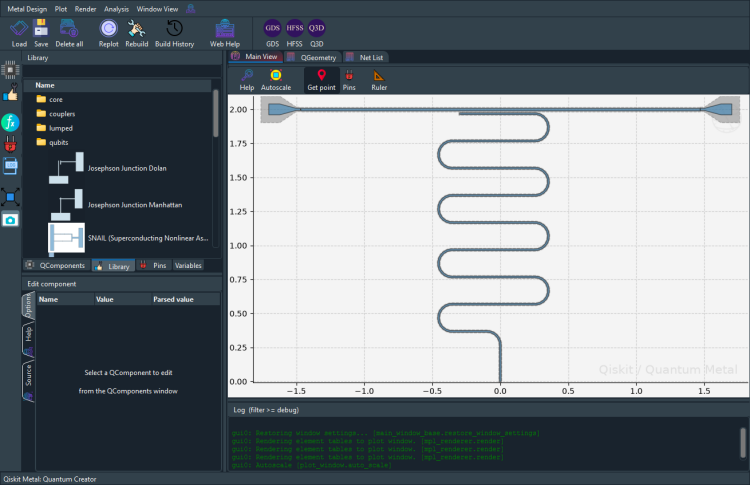

In [6]:
gui.autoscale()
gui.screenshot()

## Scattering Analysis

In [7]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim

em1 = ScatteringImpedanceSim(design, "hfss")

In [8]:
design_name = "Sweep_DrivenModal"
qcomp_render = []  # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [("LP1", "in", 50), ("LP2", "in", 50)]
box_plus_buffer = True

In [9]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 12:07PM [connect_project]: Connecting to Ansys Desktop API...
INFO 12:07PM [load_ansys_project]: 	Opened Ansys App
INFO 12:07PM [load_ansys_project]: 	Opened Ansys Desktop v2025.1.4
INFO 12:07PM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/DELL/Documents/Ansoft/
	Project:   Project283
INFO 12:07PM [connect_design]: No active design found (or error getting active design).
INFO 12:07PM [connect]: 	 Connected to project "Project283". No design detected


True

In [10]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("HangingResonator", "drivenmodal")
setup_args = Dict(max_delta_s=0.001)
setup_args.name = "Setup"
hfss.edit_drivenmodal_setup(setup_args)

12:07PM 26s WARNING [activate_ansys_design]: The design_name=HangingResonator was not in active project.  Designs in active project are: 
[].  A new design will be added to the project.  
INFO 12:08PM [connect_design]: 	Opened active design
	Design:    HangingResonator [Solution type: DrivenModal]
WARNING 12:08PM [connect_setup]: 	No design setup detected.
WARNING 12:08PM [connect_setup]: 	Creating driven modal default setup.
INFO 12:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
12:08PM 02s WARNING [edit_drivenmodal_setup]: In setup_args, key=max_delta_s, value=0.001 is not in pinfo.setup, the key/value pair from setup_args not added to Setup in Ansys.


In [11]:
# set buffer
hfss.options["x_buffer_width_mm"] = 0.1
hfss.options["y_buffer_width_mm"] = 0.1

In [12]:
# clean the design if needed
hfss.clean_active_design()

In [13]:
# render the design
hfss.render_design(
    selection=[],
    open_pins=open_terminations,
    port_list=port_list,
    box_plus_buffer=box_plus_buffer,
)

In [14]:
# for acurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length("cpw_mesh", ["trace_meander"], MaxLength="0.01mm")

## Broad sweet to find the resonance

In [15]:
hfss.add_sweep(
    setup_name="Setup",
    name="Sweep",
    start_ghz=4.0,
    stop_ghz=8.0,
    count=2001,
    type="Interpolating",
)

INFO 12:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [16]:
hfss.analyze_sweep("Sweep", "Setup")

INFO 12:08PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:08PM [analyze]: Analyzing setup Setup : Sweep


In [17]:
hfss.plot_params(["S11", "S21"])

(                      S11                 S21
 4.000 -0.040419-0.043041j -0.713828+0.697827j
 4.002 -0.040452-0.043044j -0.713558+0.698102j
 4.004 -0.040485-0.043047j -0.713287+0.698377j
 4.006 -0.040519-0.043050j -0.713016+0.698651j
 4.008 -0.040552-0.043053j -0.712745+0.698925j
 ...                   ...                 ...
 7.992 -0.091311-0.007296j -0.027840+0.995406j
 7.994 -0.091322-0.007263j -0.027456+0.995416j
 7.996 -0.091332-0.007230j -0.027072+0.995426j
 7.998 -0.091342-0.007197j -0.026688+0.995436j
 8.000 -0.091352-0.007164j -0.026303+0.995445j
 
 [2001 rows x 2 columns],
 <Figure size 1000x600 with 2 Axes>)

In [18]:
# extract the S21 parameters
freqs, Pcurves, Pparams = hfss.get_params(["S21"])

In [19]:
# find armin
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

7164000000.0

## Narrow sweep around the resonance found above

In [20]:
# fine sweep
hfss.add_sweep(
    setup_name="Setup",
    name="Sweep_narrow",
    start_ghz=np.round(f_res / 1e9, 3) - 0.01,
    stop_ghz=np.round(f_res / 1e9, 3) + 0.01,
    count=1001,
    type="Fast",
)  # slow but precise

INFO 12:14PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [21]:
hfss.analyze_sweep("Sweep_narrow", "Setup")

INFO 12:14PM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 12:14PM [analyze]: Analyzing setup Setup : Sweep_narrow


In [22]:
hfss.plot_params(["S11", "S21"])

(                        S11                 S21
 7.15400 -0.126113-0.013303j -0.147206+0.980943j
 7.15402 -0.126199-0.013284j -0.147118+0.980945j
 7.15404 -0.126284-0.013266j -0.147028+0.980948j
 7.15406 -0.126371-0.013247j -0.146939+0.980951j
 7.15408 -0.126457-0.013228j -0.146849+0.980953j
 ...                     ...                 ...
 7.17392 -0.050027-0.023551j -0.218240+0.974327j
 7.17394 -0.050096-0.023547j -0.218170+0.974340j
 7.17396 -0.050164-0.023542j -0.218101+0.974352j
 7.17398 -0.050233-0.023538j -0.218032+0.974364j
 7.17400 -0.050300-0.023533j -0.217963+0.974376j
 
 [1001 rows x 2 columns],
 <Figure size 1000x600 with 2 Axes>)

## Close connections

In [23]:
em1.close()

In [24]:
hfss.disconnect_ansys()

In [1]:
# gui.main_window.close()